In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pymongo
import os
from tensorflow.keras.utils import plot_model
import gc
from tqdm import tqdm
import tensorflow as tf
from numba import cuda
import time
import logging
from numba import cuda
cuda.select_device(0)
cuda.close()
# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to load and merge data
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Load and prepare data
merged_df = load_data()
example_user_id = 'benutzername_4'
user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=1000, random_state=42)
other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=2000, random_state=42)
combined_df = pd.concat([user_1_df, other_users_df])
X, y = prepare_images(combined_df, example_user_id)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure data type compatibility
X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_test = X_test.astype('float32')
y_test = y_test.astype('float32')

In [2]:
%pip install keras-tuner

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Conv2D(filters=hp.Int('conv_1_filter', min_value=32, max_value=128, step=16),
                     kernel_size=hp.Choice('conv_1_kernel', values=[3, 5]),
                     activation='relu',
                     input_shape=(224, 224, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=hp.Int('conv_2_filter', min_value=32, max_value=128, step=16),
                     kernel_size=hp.Choice('conv_2_kernel', values=[3, 5]),
                     activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=16), activation='relu'))
    model.add(Dropout(rate=hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

Note: you may need to restart the kernel to use updated packages.


In [3]:
from keras_tuner import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping

tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=2,  # Increase the number of trials
    executions_per_trial=1,  # Increase the number of executions per trial
    directory='my_dir',
    project_name='cnn_tuning')

tuner.search_space_summary()

tuner.search(X_train, y_train, epochs=10, validation_split=0.2, callbacks=[EarlyStopping(patience=3)])


Reloading Tuner from my_dir/cnn_tuning/tuner0.json
Search space summary
Default search space size: 7
conv_1_filter (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
conv_1_kernel (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
conv_2_filter (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
conv_2_kernel (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [4]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

history = best_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=32, callbacks=[EarlyStopping(patience=5)])

2025-02-12 15:21:19.673188: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 220, 220, 48)      3648      
                                                                 
 max_pooling2d (MaxPooling2  (None, 110, 110, 48)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 108, 108, 96)      41568     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 96)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 279936)            0         
                                                                 
 dense (Dense)               (None, 48)                1

2025-02-12 15:21:19.709111: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-02-12 15:21:19.709392: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-02-12 15:21:19.711096: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Epoch 1/50


2025-02-12 15:21:22.213608: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2025-02-12 15:21:22.470328: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-02-12 15:21:22.497119: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7456cdb76560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-02-12 15:21:22.497152: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-02-12 15:21:22.500648: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-02-12 15:21:22.597300: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.

60/60 [==============================] - 4s 29ms/step - loss: 0.7675 - accuracy: 0.4651 - val_loss: 0.5881 - val_accuracy: 0.6833
Epoch 2/50
60/60 [==============================] - 1s 21ms/step - loss: 0.6473 - accuracy: 0.5135 - val_loss: 0.7106 - val_accuracy: 0.3292
Epoch 3/50
60/60 [==============================] - 1s 21ms/step - loss: 0.6219 - accuracy: 0.5250 - val_loss: 0.4879 - val_accuracy: 0.7229
Epoch 4/50
60/60 [==============================] - 1s 21ms/step - loss: 0.5403 - accuracy: 0.6021 - val_loss: 0.4882 - val_accuracy: 0.8042
Epoch 5/50
60/60 [==============================] - 1s 21ms/step - loss: 0.5020 - accuracy: 0.6568 - val_loss: 0.3987 - val_accuracy: 0.6875
Epoch 6/50
60/60 [==============================] - 1s 20ms/step - loss: 0.4955 - accuracy: 0.6703 - val_loss: 0.3903 - val_accuracy: 0.6875
Epoch 7/50
60/60 [==============================] - 1s 20ms/step - loss: 0.4935 - accuracy: 0.6703 - val_loss: 0.3981 - val_accuracy: 0.6875
Epoch 8/50
60/60 [======

Number of samples used for testing: 600
19/19 [==============================] - 0s 13ms/step
Evaluation Metrics:
Accuracy: 0.8100
Precision: 0.8047
Recall: 0.6267
F1 Score: 0.7047
ROC AUC: 0.9189


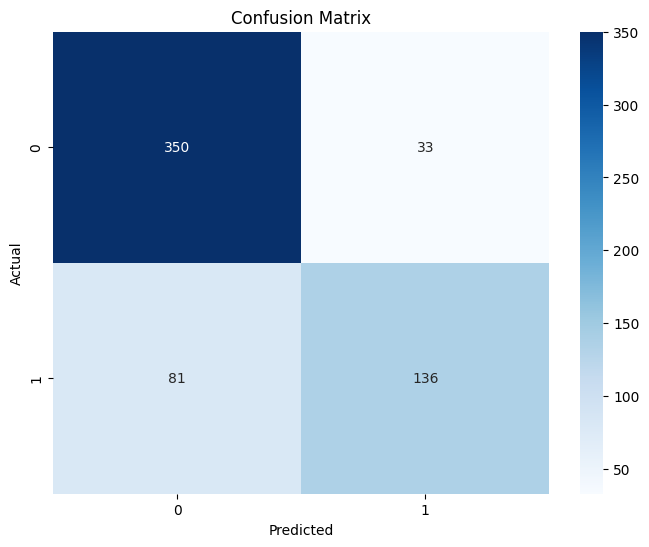

Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.91      0.86       383
         1.0       0.80      0.63      0.70       217

    accuracy                           0.81       600
   macro avg       0.81      0.77      0.78       600
weighted avg       0.81      0.81      0.80       600



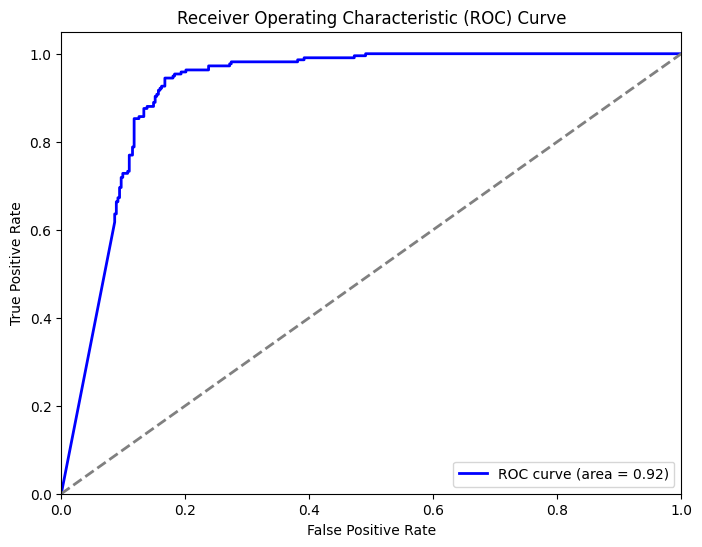

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred_labels, y_pred_probs):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred_labels),
        'Precision': precision_score(y_true, y_pred_labels),
        'Recall': recall_score(y_true, y_pred_labels),
        'F1 Score': f1_score(y_true, y_pred_labels),
        'ROC AUC': roc_auc_score(y_true, y_pred_probs)
    }
    return metrics

# Display the number of samples used for testing
print(f"Number of samples used for testing: {len(X_test)}")
y_pred = best_model.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)

metrics = evaluate_model(y_test, y_pred_labels, y_pred)
print("Evaluation Metrics:")
for metric, value in metrics.items():
    if value is not None:
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: None")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
class_report = classification_report(y_test, y_pred_labels)
print("Classification Report:\n", class_report)

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

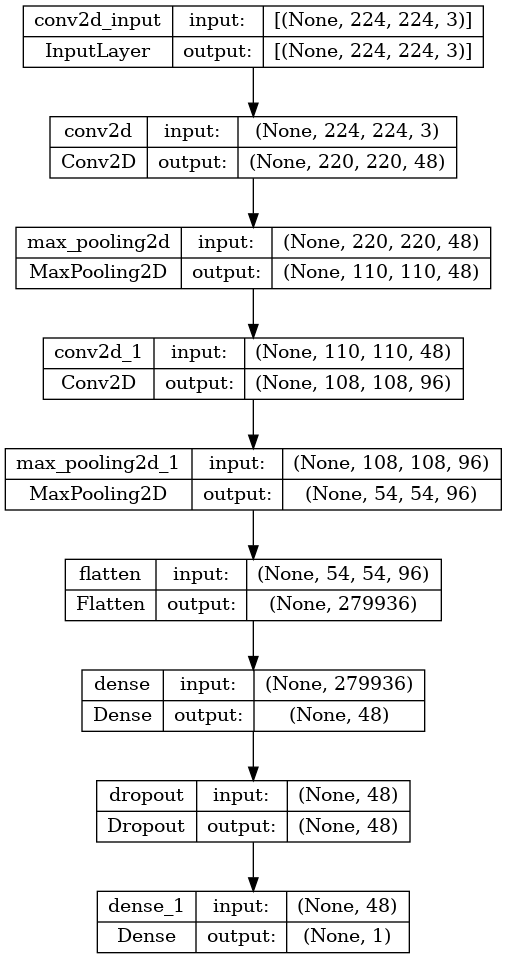

In [6]:
# Import necessary libraries
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# Plot model architecture
plot_model(best_model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the model architecture image
display(Image(filename='model_architecture.png'))


Loading and merging data from MongoDB...
Data loaded and merged successfully.
Preparing images and labels...
Images and labels prepared successfully.
Evaluating the model...
69/69 [==============================] - 3s 8ms/step


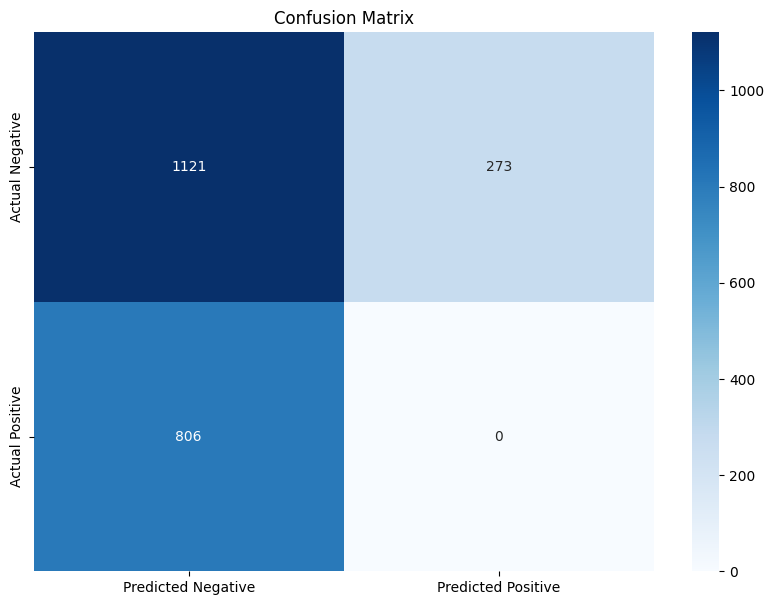

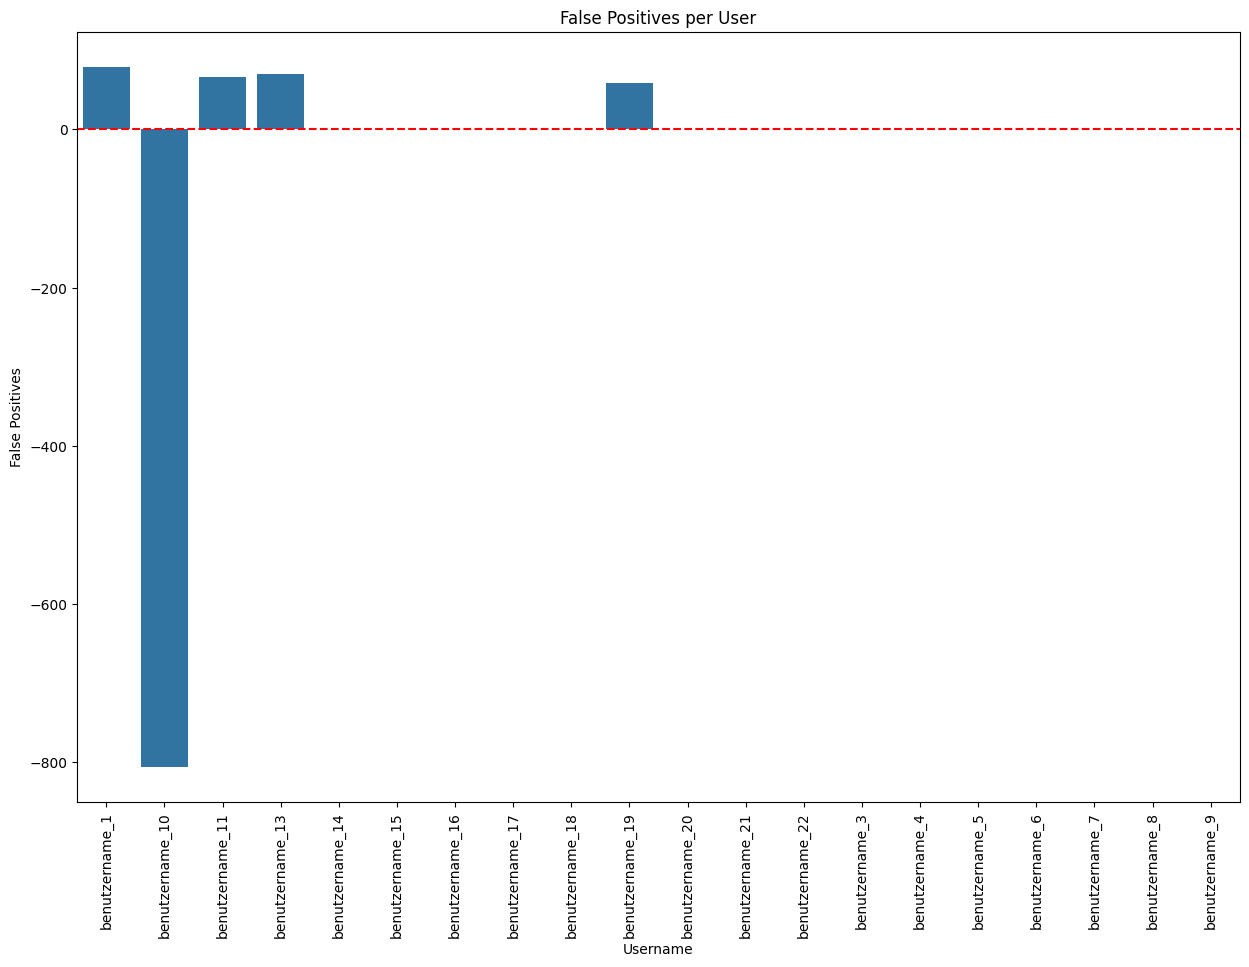

Model evaluation completed.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
import pymongo
import os
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to load and merge data
def load_data():
    print("Loading and merging data from MongoDB...")
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    print("Data loaded and merged successfully.")
    return merged_df

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        logging.error(f"Error processing image: {e}")
        return None

# Function to prepare images and labels
def prepare_images(df, example_user_id):
    print("Preparing images and labels...")
    images = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    print("Images and labels prepared successfully.")
    return np.array(images), np.array(labels)

# Load and prepare data
merged_df = load_data()
example_user_id = 'benutzername_4'
user_1_df = merged_df[merged_df['username'] == example_user_id].sample(n=4000, random_state=42)
other_users_df = merged_df[merged_df['username'] != example_user_id].sample(n=7000, random_state=42)
combined_df = pd.concat([user_1_df, other_users_df])
X, y = prepare_images(combined_df, example_user_id)

# Split the data and get the indices
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, combined_df.index, test_size=0.2, random_state=42)

# Ensure data type compatibility
X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_test = X_test.astype('float32')
y_test = y_test.astype('float32')

# Function to evaluate the model
def evaluate_model(model, X_test, y_test, test_df, example_user_id):
    print("Evaluating the model...")
    y_pred_probs = model.predict(X_test)
    y_pred_labels = (y_pred_probs > 0.5).astype(int)

    # Create a DataFrame with the results
    results_df = test_df.copy()
    results_df['predicted'] = y_pred_labels
    results_df['actual'] = y_test

    # Create a confusion matrix
    cm = confusion_matrix(y_test, y_pred_labels)
    cm_df = pd.DataFrame(cm, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive'])

    # Plot the confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

    # Plot the results for each user
    user_results = results_df.groupby('username').agg({'predicted': 'sum', 'actual': 'sum'}).reset_index()
    user_results['false_positive'] = user_results['predicted'] - user_results['actual']

    plt.figure(figsize=(15, 10))
    sns.barplot(x='username', y='false_positive', data=user_results)
    plt.axhline(0, color='red', linestyle='--')
    plt.title('False Positives per User')
    plt.xlabel('Username')
    plt.ylabel('False Positives')
    plt.xticks(rotation=90)
    plt.show()
    print("Model evaluation completed.")

# Use the currently trained model from the notebook
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the model
evaluate_model(best_model, X_test, y_test, combined_df.loc[test_idx], example_user_id)

2025-02-12 15:37:10,534 - WARNING - Detecting that an object or model or tf.train.Checkpoint is being deleted with unrestored values. See the following logs for the specific values in question. To silence these warnings, use `status.expect_partial()`. See https://www.tensorflow.org/api_docs/python/tf/train/Checkpoint#restorefor details about the status object returned by the restore function.


2025-02-12 15:37:10,539 - WARNING - Value in checkpoint could not be found in the restored object: (root).optimizer._variables.1


2025-02-12 15:37:10,539 - WARNING - Value in checkpoint could not be found in the restored object: (root).optimizer._variables.2


2025-02-12 15:37:10,540 - WARNING - Value in checkpoint could not be found in the restored object: (root).optimizer._variables.3


2025-02-12 15:37:10,541 - WARNING - Value in checkpoint could not be found in the restored object: (root).optimizer._variables.4


...

2025-02-12 15:37:35,963 - WARNING - Value in checkpoint could not be found in the restored object: (root).optimizer._variables.13


2025-02-12 15:37:35,965 - WARNING - Value in checkpoint could not be found in the restored object: (root).optimizer._variables.14


2025-02-12 15:37:35,966 - WARNING - Value in checkpoint could not be found in the restored object: (root).optimizer._variables.15


2025-02-12 15:37:35,967 - WARNING - Value in checkpoint could not be found in the restored object: (root).optimizer._variables.16


Data loaded and merged successfully.
69/69 [==============================] - 1s 11ms/step


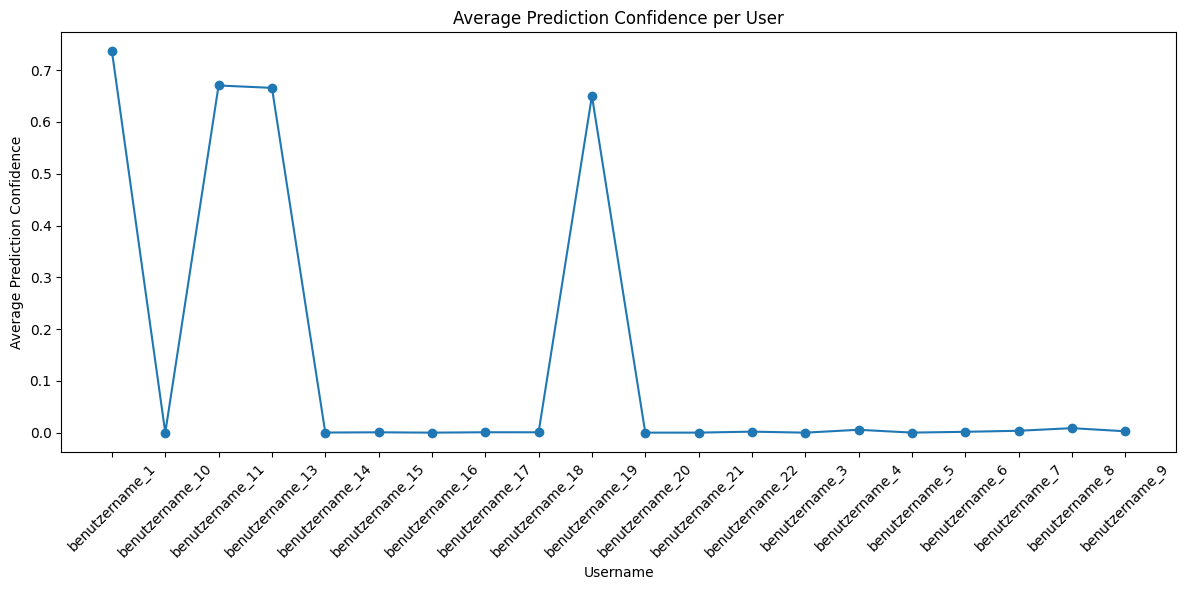

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io, base64
import pymongo, os
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model

# --- Data Loading and Image Processing Functions ---

def load_data():
    print("Loading and merging data from MongoDB...")
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    print("Data loaded and merged successfully.")
    return merged_df

def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0
        return image_array
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

def prepare_images(df, example_user_id):
    images = []
    usernames = []
    labels = []
    for _, row in df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            usernames.append(row['username'])
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels), np.array(usernames)

# --- Main Code ---

# Hardcoded settings
example_user_id = 'benutzername_4'  # User to test
# Use the same model as in the notebook (assumed available via tuner)
best_model = tuner.get_best_models(num_models=1)[0]

# Load and prepare data
merged_df = load_data()
user_samples = merged_df[merged_df['username'] == example_user_id].sample(n=4000, random_state=42)
other_samples = merged_df[merged_df['username'] != example_user_id].sample(n=7000, random_state=42)
combined_df = pd.concat([user_samples, other_samples])
X, y_dummy, usernames = prepare_images(combined_df, example_user_id)

# Split data: We need to retain usernames for grouping
_, X_test, _, y_test_usernames = train_test_split(X, usernames, test_size=0.2, random_state=42)

# Predict probabilities using the trained model
y_pred_probs = best_model.predict(X_test).flatten()

# Create DataFrame of usernames and corresponding prediction confidence
df_plot = pd.DataFrame({
    'username': y_test_usernames,
    'confidence': y_pred_probs
})

# Calculate average confidence per user
mean_confidence = df_plot.groupby('username', as_index=False)['confidence'].mean()
mean_confidence = mean_confidence.sort_values('username')  # sort alphabetically (or adjust as needed)

# Plot a line graph showing average prediction confidence per user
plt.figure(figsize=(12, 6))
plt.plot(mean_confidence['username'], mean_confidence['confidence'], marker='o', linestyle='-')
plt.title('Average Prediction Confidence per User')
plt.xlabel('Username')
plt.ylabel('Average Prediction Confidence')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pymongo
import os

def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    return merged_df

def process_image(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0
        return image_array
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

def test_user_samples(username='benutzername_4', num_samples=100, model_path='my_dir/cnn_tuning/'):
    # Load data
    print(f"Loading data for user {username}...")
    merged_df = load_data()
    
    # Get user samples
    user_samples = merged_df[merged_df['username'] == username].sample(n=num_samples, random_state=42)
    other_samples = merged_df[merged_df['username'] != username].sample(n=num_samples, random_state=42)
    test_df = pd.concat([user_samples, other_samples])
    
    # Process images
    print("Processing images...")
    images = []
    labels = []
    for _, row in test_df.iterrows():
        img = process_image(row['sampleData'])
        if img is not None:
            images.append(img)
            labels.append(1 if row['username'] == username else 0)
    
    X_test = np.array(images)
    y_test = np.array(labels)
    
    # Load and test model
    print("Loading model...")
    model = tf.keras.models.load_model(model_path)
    
    print("Making predictions...")
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Visualize results
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Prediction Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(data=y_pred_probs, hue=y_test, bins=20)
    plt.title(f'Prediction Distribution for {username}')
    plt.xlabel('Prediction Confidence')
    plt.ylabel('Count')
    
    # Plot 2: Metrics
    plt.subplot(1, 2, 2)
    metrics = ['Accuracy', 'Precision', 'Recall']
    values = [accuracy, precision, recall]
    plt.bar(metrics, values)
    plt.title(f'Model Performance Metrics for {username}')
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\nResults for {username}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

# Run test with hardcoded values
test_user_samples()

Loading data for user benutzername_4...
Processing images...
Loading model...


OSError: SavedModel file does not exist at: my_dir/cnn_tuning//{saved_model.pbtxt|saved_model.pb}

In [ ]:
import json
import os

# Pfad zur JSON-Datei
json_file_path = '/home/lion/IDentify/fingerprintDB.fingerprints.json'

# Funktion zum Laden der JSON-Daten
def load_json_data(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

# Funktion zum Auflisten der Benutzerdaten
def list_user_data(data):
    for user in data:
        username = user.get('username', 'N/A')
        device_name = user.get('deviceName', 'N/A')
        operating_system = user.get('operatingSystem', 'N/A')
        canvas_sample_count = user.get('canvasSampleCount', 'N/A')
        user_agent = json.loads(user.get('fingerprint', '{}')).get('UserAgent', 'N/A')
        
        print(f"Benutzername: {username}")
        print(f"Gerätename: {device_name}")
        print(f"Betriebssystem: {operating_system}")
        print(f"Anzahl der Samples: {canvas_sample_count}")
        print(f"User Agent: {user_agent}")
        print("-" * 40)

# JSON-Daten laden
data = load_json_data(json_file_path)

# Benutzerdaten auflisten
list_user_data(data)